In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install timm==0.9.12
!pip install matplotlib seaborn scikit-learn h5py


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

import matplotlib.pyplot as plt
import numpy as np
import timm
import os
import h5py
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [4]:
DATASET_ROOT = "/content/drive/MyDrive/morph_project/processed"

TRAIN_H5 = DATASET_ROOT + "/train.h5"
TEST_H5  = DATASET_ROOT + "/test.h5"

with h5py.File(TRAIN_H5, 'r') as f:
    X_train_full = np.array(f["X"])
    y_train_full = np.array(f["y"])

with h5py.File(TEST_H5, 'r') as f:
    X_test = np.array(f["X"])
    y_test = np.array(f["y"])

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (5741, 224, 224, 3)
Validation: (1436, 224, 224, 3)
Test: (1803, 224, 224, 3)


In [5]:
class NumpyDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx].astype(np.uint8)
        img = transforms.ToPILImage()(img)
        label = int(self.y[idx])

        if self.transform:
            img = self.transform(img)

        return img, label


In [6]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.3)
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


In [13]:
train_dataset = NumpyDataset(X_train, y_train, transform_train)
val_dataset   = NumpyDataset(X_val, y_val, transform_test)
test_dataset  = NumpyDataset(X_test, y_test, transform_test)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False, drop_last=False)


print("Dataloaders ready!")


Dataloaders ready!


In [8]:
class Swin224Classifier(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()

        self.backbone = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=True,
            num_classes=0,
            drop_path_rate=0.2
        )

        in_features = self.backbone.num_features

        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x

model = Swin224Classifier().to(device)


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

In [9]:
freeze_ratio = 0.7
params = list(model.backbone.parameters())
freeze_until = int(len(params) * freeze_ratio)

for i, p in enumerate(params):
    if i < freeze_until:
        p.requires_grad = False

print("Backbone partially frozen (70%).")


Backbone partially frozen (70%).


In [10]:
from timm.data.mixup import Mixup

mixup_fn = Mixup(
    mixup_alpha=0.2,
    cutmix_alpha=0.2,
    prob=0.5,
    num_classes=2
)


In [11]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-5,
    weight_decay=0.05
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=15,
    eta_min=1e-6
)


In [15]:
# ============================
# FINAL TRAINING LOOP (FIXED)
# ============================

scaler = torch.amp.GradScaler(device.type)

best_val_acc = 0
best_model_path = "/content/drive/MyDrive/morph_project/swin224_best.pth"

def accuracy(outputs, labels):
    return (outputs.argmax(1) == labels).float().mean().item()

for epoch in range(15):
    model.train()
    train_loss = 0
    train_acc = 0

    for imgs, labels in train_loader:   # train_loader has drop_last=True
        imgs, labels = imgs.to(device), labels.to(device)

        # Mixup only when batch is even (but drop_last ensures it always is)
        if imgs.size(0) % 2 == 0:
            imgs, labels = mixup_fn(imgs, labels)

        optimizer.zero_grad()

        with torch.amp.autocast(device.type):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

        # For mixup labels → need argmax
        train_acc += accuracy(outputs, labels.argmax(1))

    scheduler.step()

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    val_acc = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            with torch.amp.autocast(device.type):
                outputs = model(imgs)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            val_acc += accuracy(outputs, labels)

    epoch_train_acc = train_acc / len(train_loader)
    epoch_val_acc = val_acc / len(val_loader)

    print(f"Epoch {epoch+1}/15 | Train Acc: {epoch_train_acc:.4f} | Val Acc: {epoch_val_acc:.4f}")

    # Save best model
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), best_model_path)
        print("🔥 Saved best model!")


Epoch 1/15 | Train Acc: 0.8312 | Val Acc: 0.8333
🔥 Saved best model!
Epoch 2/15 | Train Acc: 0.8389 | Val Acc: 0.8396
🔥 Saved best model!
Epoch 3/15 | Train Acc: 0.8427 | Val Acc: 0.8444
🔥 Saved best model!
Epoch 4/15 | Train Acc: 0.8485 | Val Acc: 0.8465
🔥 Saved best model!
Epoch 5/15 | Train Acc: 0.8550 | Val Acc: 0.8486
🔥 Saved best model!
Epoch 6/15 | Train Acc: 0.8609 | Val Acc: 0.8451
Epoch 7/15 | Train Acc: 0.8680 | Val Acc: 0.8444
Epoch 8/15 | Train Acc: 0.8701 | Val Acc: 0.8424
Epoch 9/15 | Train Acc: 0.8726 | Val Acc: 0.8417
Epoch 10/15 | Train Acc: 0.8792 | Val Acc: 0.8486
Epoch 11/15 | Train Acc: 0.8818 | Val Acc: 0.8403
Epoch 12/15 | Train Acc: 0.8858 | Val Acc: 0.8451
Epoch 13/15 | Train Acc: 0.8863 | Val Acc: 0.8417
Epoch 14/15 | Train Acc: 0.8813 | Val Acc: 0.8444
Epoch 15/15 | Train Acc: 0.8877 | Val Acc: 0.8451


In [16]:
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0     0.8547    0.9758    0.9113      1489
           1     0.6505    0.2134    0.3213       314

    accuracy                         0.8430      1803
   macro avg     0.7526    0.5946    0.6163      1803
weighted avg     0.8191    0.8430    0.8085      1803



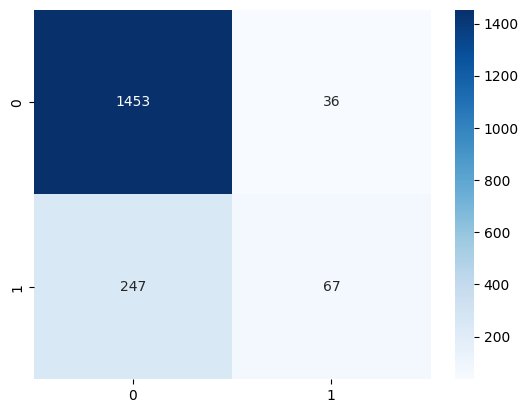

In [17]:
print("=== CLASSIFICATION REPORT ===")
print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.show()


In [18]:
import torch
import numpy as np

model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds = []
all_labels = []
all_probs = []

softmax = nn.Softmax(dim=1)

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)

        outputs = model(imgs)

        probs = softmax(outputs)[:, 1].cpu().numpy()   # Probability of class "1"
        preds = outputs.argmax(1).cpu().numpy()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

print("Done — collected predictions, probabilities, and labels.")


Done — collected predictions, probabilities, and labels.


In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))


Precision: 0.6505
Recall: 0.2134
F1 Score: 0.3213


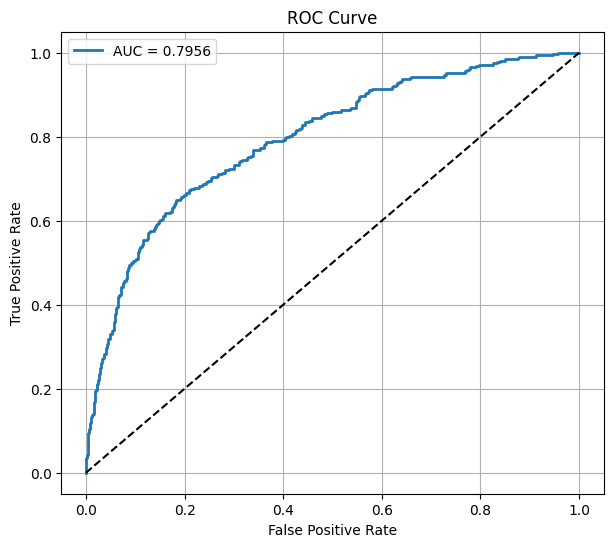

AUC Score: 0.7956


In [20]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
auc_value = roc_auc_score(all_labels, all_probs)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_value:.4f}")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

print("AUC Score:", round(auc_value, 4))



=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0     0.8547    0.9758    0.9113      1489
           1     0.6505    0.2134    0.3213       314

    accuracy                         0.8430      1803
   macro avg     0.7526    0.5946    0.6163      1803
weighted avg     0.8191    0.8430    0.8085      1803



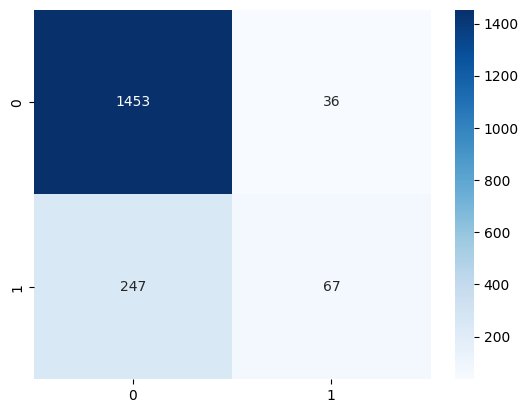

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.show()


In [23]:
from google.colab import files
from PIL import Image
import torch
import torch.nn as nn
import timm
from torchvision import transforms

# ============================================
# 1. Device
# ============================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================================
# 2. Define Swin-Tiny 224 Classifier
# ============================================
class Swin224Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=False,   # IMPORTANT: no pretrained during inference
            num_classes=0
        )

        in_features = self.backbone.num_features

        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x


# ============================================
# 3. Load Best Saved Model From Drive
# ============================================
model_path = "/content/drive/MyDrive/morph_project/swin224_best.pth"

model = Swin224Classifier().to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

print("🔥 Best Swin-Tiny 224 Model Loaded Successfully!")


# ============================================
# 4. Inference Transform (224x224)
# ============================================
infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])


# ============================================
# 5. Prediction Function
# ============================================
def predict_user_image(model, img_path):
    img = Image.open(img_path).convert("RGB")

    img_tensor = infer_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()

    classes = ["Licit", "Illicit"]
    confidence = float(probs[0][pred_class])

    print("\n=============================")
    print(" Image:", img_path)
    print(" Prediction:", classes[pred_class])
    print(" Confidence:", round(confidence, 4))
    print("=============================")


# ============================================
# 6. Upload + Predict
# ============================================
uploaded = files.upload()

for filename in uploaded.keys():
    predict_user_image(model, filename)


Using device: cuda
🔥 Best Swin-Tiny 224 Model Loaded Successfully!


Saving casias1.png to casias1.png

 Image: casias1.png
 Prediction: Licit
 Confidence: 0.8087
